# **Optimización analítica y métodos numéricos con `SymPy`, `NumPy` y `Matplotlib`**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franperezec/propedeutico-flacso/blob/main/clases/calculo_simbolico/sympy_optimizacion.ipynb)

**Profesor:** Francisco Pérez M. · **Propedéutico de Matemáticas y Programación · FLACSO Ecuador**

## De $\mathbb{R}\to\mathbb{R}$ a $\mathbb{R}^n\to\mathbb{R}$

Este notebook presenta una ruta progresiva para estudiantes que utilizan por primera vez `sympy`, `numpy` y `matplotlib`.

La organización separa deliberadamente dos enfoques:

1. **Ruta principal: optimización analítica.** Se calculan derivadas, se resuelven las condiciones de primer orden y se clasifican los puntos mediante condiciones de segundo orden.
2. **Comprobación numérica.** Tras resolver el ejemplo de dos productos por la vía analítica, se verifica que el ascenso por gradiente llega a la misma solución.

## Objetivos de aprendizaje

Al finalizar, el estudiante podrá:

- reconocer las dimensiones de escalares, vectores, gradientes y Hessianas;
- comprobar si un producto matricial está bien conformado;
- usar Taylor de primer y segundo orden;
- interpretar la linealización como recta o hiperplano tangente;
- aplicar CPO y CSO en $\mathbb{R}\to\mathbb{R}$ y $\mathbb{R}^n\to\mathbb{R}$;
- clasificar Hessianas mediante autovalores, formas cuadráticas y menores principales líderes;
- resolver ejemplos económicos con `sympy` y graficarlos con `matplotlib`;
- comprender por qué los métodos de gradiente son útiles en problemas con muchas variables, como la estimación de redes neuronales.

> **Nivel:** introductorio. Los comandos se repiten de manera deliberada y cada cálculo se acompaña de su dimensión.

## Preparación del entorno

### Google Colab

Las bibliotecas suelen estar instaladas. Si aparece un error, ejecute una sola vez:

```python
%pip install sympy numpy matplotlib
```

### VS Code

**Windows — PowerShell**

```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install sympy numpy matplotlib ipykernel
```

**macOS o Linux**

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install sympy numpy matplotlib ipykernel
```

En VS Code, abra el notebook y seleccione como kernel el intérprete de `.venv`.

In [6]:
# Ejecute esta celda solo si necesita instalar las bibliotecas.
# Quite el símbolo # de la línea siguiente y ejecútela una sola vez.
# %pip install sympy numpy matplotlib


In [1]:
%matplotlib inline

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# Presentación matemática de las expresiones simbólicas.
sp.init_printing(use_latex='mathjax')


# 0. Mapa dimensional de los objetos

Sea

$$
F:\mathbb{R}^n\longrightarrow\mathbb{R},
\qquad
\mathbf{x}\longmapsto F(\mathbf{x}).
$$

Adoptaremos estas convenciones:

- $\mathbf{x}$ es un vector columna de dimensión $n\times 1$;
- $F(\mathbf{x})$ es un escalar;
- el gradiente de una función escalar es un vector columna.

| Objeto | Notación | Dimensión |
|---|---|---:|
| Variable de decisión | $\mathbf{x}$ | $n\times1$ |
| Incremento | $\mathbf{h}$ | $n\times1$ |
| Valor | $F(\mathbf{x})$ | escalar $1\times1$ |
| Gradiente | $\nabla F(\mathbf{x})$ | $n\times1$ |
| Jacobiana de $F$ | $J_F=\nabla F^T$ | $1\times n$ |
| Hessiana | $H_F(\mathbf{x})$ | $n\times n$ |

## Regla de compatibilidad

Si $A$ tiene dimensión $p\times q$ y $B$ tiene dimensión $q\times r$, entonces

$$
AB\in\mathbb{R}^{p\times r}.
$$

Las **dimensiones interiores** deben coincidir.

## 0.1. Productos que aparecerán en el notebook

| Expresión | Dimensiones | Resultado |
|---|---|---:|
| $\nabla F^T\mathbf{h}$ | $(1\times n)(n\times1)$ | escalar |
| $\mathbf{h}^TH_F\mathbf{h}$ | $(1\times n)(n\times n)(n\times1)$ | escalar |

Esta revisión dimensional evita errores como intentar sumar un gradiente $n\times1$ con un escalar.

In [2]:
# Pequeña comprobación de dimensiones con matrices simbólicas.
n_demo = 3

g_demo = sp.zeros(n_demo, 1)   # gradiente: 3 x 1
h_demo = sp.zeros(n_demo, 1)   # incremento: 3 x 1
H_demo = sp.eye(n_demo)        # Hessiana: 3 x 3

print('g_demo:', g_demo.shape)
print('h_demo:', h_demo.shape)
print('g_demo.T * h_demo:', (g_demo.T * h_demo).shape)
print('h_demo.T * H_demo * h_demo:', (h_demo.T * H_demo * h_demo).shape)

g_demo: (3, 1)
h_demo: (3, 1)
g_demo.T * h_demo: (1, 1)
h_demo.T * H_demo * h_demo: (1, 1)


# 1. Funciones escalares $f:\mathbb{R}\to\mathbb{R}$

## 1.1. Aproximaciones de Taylor

Sea $x_0$ un punto base y $h$ un incremento pequeño.

### Primer orden

$$
\boxed{
f(x_0+h)=f(x_0)+f'(x_0)h+o(|h|)
}
$$

La linealización es

$$
\boxed{
L(x)=f(x_0)+f'(x_0)(x-x_0)
}
$$

y representa la **recta tangente** a la gráfica de $f$ en $x_0$.

### Segundo orden

$$
\boxed{
f(x_0+h)
=f(x_0)+f'(x_0)h+\frac12 f''(x_0)h^2+o(h^2)
}
$$

El término $f'(x_0)h$ describe la pendiente local y el término $\frac12f''(x_0)h^2$ incorpora la curvatura.

## 1.2. Condiciones de primer y segundo orden

Si $x^*$ es un óptimo local interior y $f$ es diferenciable, la **condición necesaria de primer orden** es

$$
\boxed{f'(x^*)=0.}
$$

En un punto crítico:

| Segunda derivada | Conclusión |
|---|---|
| $f''(x^*)>0$ | mínimo local estricto |
| $f''(x^*)<0$ | máximo local estricto |
| $f''(x^*)=0$ | criterio inconcluso |

Como condiciones necesarias de segundo orden:

- en un mínimo local, $f''(x^*)\ge 0$;
- en un máximo local, $f''(x^*)\le 0$.

Los signos estrictos constituyen condiciones suficientes.

## 1.3. Aplicación: beneficio de una empresa

Una empresa enfrenta

$$
p(q)=50-q,
\qquad
C(q)=10q+100.
$$

El beneficio es

$$
\pi(q)=p(q)q-C(q).
$$

Buscaremos la cantidad $q^*$ que maximiza el beneficio.

In [3]:
# Variable simbólica.
q = sp.symbols('q', real=True)

# Precio, ingreso, costo y beneficio.
precio = 50 - q
ingreso = precio*q
costo = 10*q + 100
beneficio_q = sp.expand(ingreso - costo)

print('Beneficio:')
display(beneficio_q)


Beneficio:


   2             
- q  + 40⋅q - 100

In [4]:
# Primera y segunda derivadas.
beneficio_q_1 = sp.diff(beneficio_q, q)
beneficio_q_2 = sp.diff(beneficio_q, q, 2)

# Condición de primer orden.
soluciones_q = sp.solve(beneficio_q_1, q)
q_star = soluciones_q[0]

# Clasificación.
segunda_en_q_star = sp.simplify(beneficio_q_2.subs(q, q_star))

if segunda_en_q_star > 0:
    clasificacion_q = 'mínimo local'
elif segunda_en_q_star < 0:
    clasificacion_q = 'máximo local'
else:
    clasificacion_q = 'criterio inconcluso'

beneficio_star_q = sp.simplify(beneficio_q.subs(q, q_star))

print("pi'(q) =")
display(beneficio_q_1)
print("pi''(q) =")
display(beneficio_q_2)
print('q* =', q_star)
print('Clasificación:', clasificacion_q)
print('Beneficio máximo =', beneficio_star_q)

assert q_star == 20
assert beneficio_star_q == 300


pi'(q) =


40 - 2⋅q

pi''(q) =


-2

q* = 20
Clasificación: máximo local
Beneficio máximo = 300


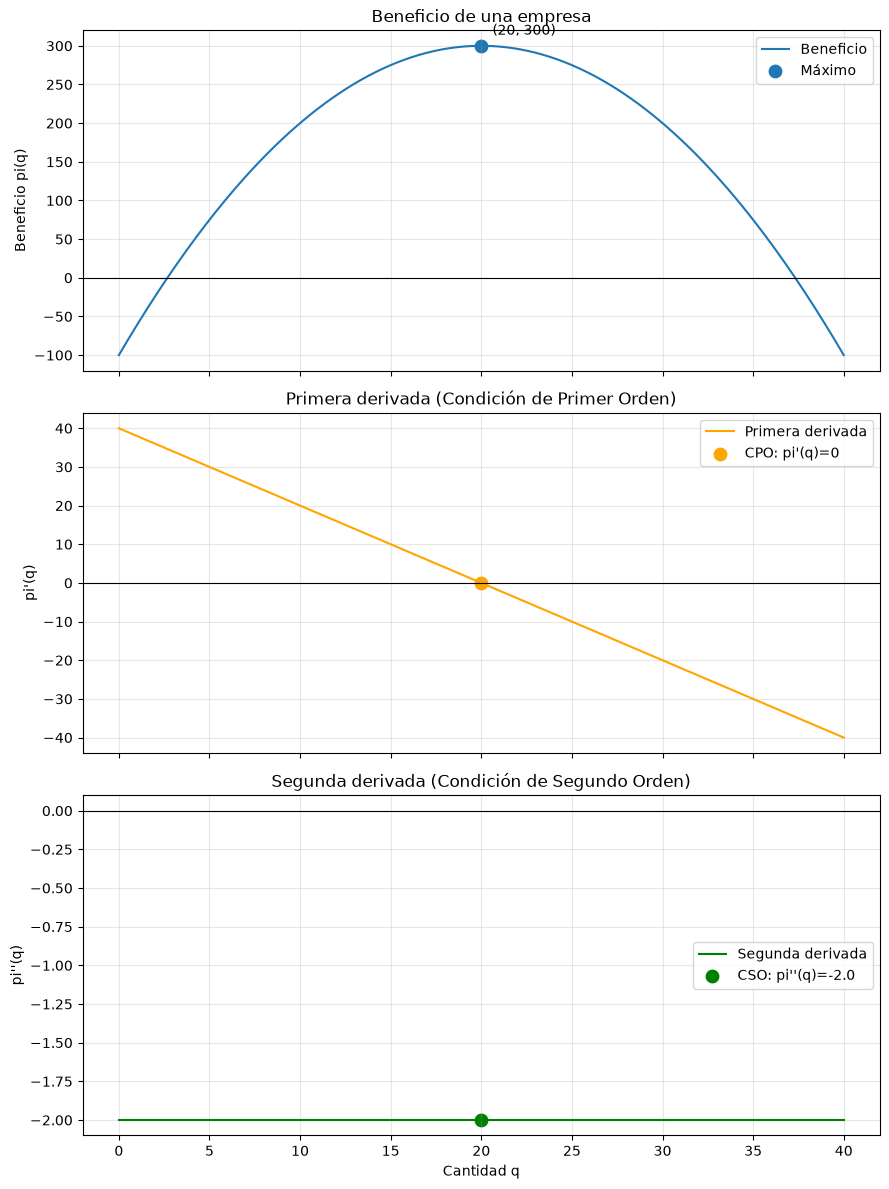

In [5]:
# Convertimos la expresión simbólica en funciones numéricas.
beneficio_q_np = sp.lambdify(q, beneficio_q, 'numpy')
beneficio_q_1_np = sp.lambdify(q, beneficio_q_1, 'numpy')
beneficio_q_2_np = sp.lambdify(q, beneficio_q_2, 'numpy')

q_valores = np.linspace(0, 40, 300)
pi_valores = beneficio_q_np(q_valores)
pi_1_valores = beneficio_q_1_np(q_valores)
# La segunda derivada es constante, por lo que creamos un arreglo del mismo tamaño
pi_2_valores = np.full_like(q_valores, beneficio_q_2_np(q_valores))

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 12), sharex=True)

# Gráfico del beneficio
ax1.plot(q_valores, pi_valores, label='Beneficio')
ax1.scatter(float(q_star), float(beneficio_star_q), s=80, label='Máximo')
ax1.annotate(f'({float(q_star):.0f}, {float(beneficio_star_q):.0f})',
             (float(q_star), float(beneficio_star_q)),
             xytext=(8, 8), textcoords='offset points')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Beneficio de una empresa')
ax1.set_ylabel('Beneficio pi(q)')
ax1.grid(alpha=0.3)
ax1.legend()

# Gráfico de la primera derivada
ax2.plot(q_valores, pi_1_valores, color='orange', label='Primera derivada')
ax2.scatter(float(q_star), 0, s=80, color='orange', label='CPO: pi\'(q)=0')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Primera derivada (Condición de Primer Orden)')
ax2.set_ylabel("pi'(q)")
ax2.grid(alpha=0.3)
ax2.legend()

# Gráfico de la segunda derivada
ax3.plot(q_valores, pi_2_valores, color='green', label='Segunda derivada')
ax3.scatter(float(q_star), float(beneficio_q_2), s=80, color='green', label=f"CSO: pi''(q)={float(beneficio_q_2)}")
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title('Segunda derivada (Condición de Segundo Orden)')
ax3.set_xlabel('Cantidad q')
ax3.set_ylabel("pi''(q)")
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()


# 2. Funciones multivariadas $F:\mathbb{R}^n\to\mathbb{R}$

## 2.1. Aproximación de primer orden e hiperplano tangente

Sean

$$
\mathbf{x}_0\in\mathbb{R}^n,
\qquad
\mathbf{h}\in\mathbb{R}^n.
$$

Si $F$ es diferenciable,

$$
\boxed{
F(\mathbf{x}_0+\mathbf{h})
=F(\mathbf{x}_0)
+\nabla F(\mathbf{x}_0)^T\mathbf{h}
+o(\|\mathbf{h}\|)
}
$$

La linealización alrededor de $\mathbf{x}_0$ es

$$
\boxed{
L(\mathbf{x})
=F(\mathbf{x}_0)
+\nabla F(\mathbf{x}_0)^T(\mathbf{x}-\mathbf{x}_0)
}
$$

Geométricamente, $L$ es el **hiperplano tangente** a la gráfica de $F$ en el punto $(\mathbf{x}_0,F(\mathbf{x}_0))\in\mathbb{R}^{n+1}$.

Comprobación dimensional:

$$
\underbrace{\nabla F(\mathbf{x}_0)^T}_{1\times n}
\underbrace{(\mathbf{x}-\mathbf{x}_0)}_{n\times1}
\;\in\;\mathbb{R}.
$$

Esta aproximación lineal será la base de los métodos de gradiente que se presentan más adelante (subsecciones 2.5 y 3.2).

## 2.2. Aproximación de segundo orden y forma cuadrática

Si $F$ tiene segundas derivadas continuas,

$$
\boxed{
F(\mathbf{x}_0+\mathbf{h})
=F(\mathbf{x}_0)
+\nabla F(\mathbf{x}_0)^T\mathbf{h}
+\frac12\mathbf{h}^TH_F(\mathbf{x}_0)\mathbf{h}
+o(\|\mathbf{h}\|^2)
}
$$

El término

$$
\boxed{Q(\mathbf{h})=\mathbf{h}^TH_F(\mathbf{x}_0)\mathbf{h}}
$$

es una **forma cuadrática**. Su signo describe la curvatura local.

Dimensiones:

$$
\underbrace{\mathbf{h}^T}_{1\times n}
\underbrace{H_F}_{n\times n}
\underbrace{\mathbf{h}}_{n\times1}
\;\in\;\mathbb{R}.
$$

## 2.3. Condiciones de optimización y clasificación de la Hessiana

### Condición necesaria de primer orden

Si $\mathbf{x}^*$ es un óptimo local interior y $F$ es diferenciable,

$$
\boxed{\nabla F(\mathbf{x}^*)=\mathbf{0}.}
$$

Esta ecuación produce **candidatos**. No clasifica por sí sola.

### Condiciones de segundo orden

En un punto crítico, el término lineal desaparece y

$$
F(\mathbf{x}^*+\mathbf{h})-F(\mathbf{x}^*)
\approx
\frac12\mathbf{h}^TH_F(\mathbf{x}^*)\mathbf{h}.
$$

El signo de la forma cuadrática $Q(\mathbf{h})=\mathbf{h}^TH_F(\mathbf{x}^*)\mathbf{h}$ decide la clasificación. Existen tres criterios equivalentes para determinarlo; los resumimos juntos, en el orden en que los usaremos.

### Criterio 1 — Autovalores (el que usaremos en código)

Para una Hessiana simétrica:

| Autovalores | Clasificación de $H$ | Punto crítico |
|---|---|---|
| todos $\lambda_i>0$ | definida positiva | mínimo local estricto |
| todos $\lambda_i<0$ | definida negativa | máximo local estricto |
| algunos positivos y otros negativos | indefinida | punto de silla |
| aparecen ceros y no hay mezcla de signos | semidefinida o caso degenerado | prueba inconclusa |

En `NumPy` utilizaremos

```python
np.linalg.eigvalsh(H)
```

porque `eigvalsh` está diseñado para matrices simétricas.

**Tolerancia numérica.** En cálculo simbólico, un autovalor puede ser exactamente cero. En cálculo numérico, el mismo valor podría aparecer como $10^{-16}$ o $-10^{-16}$ por efectos del punto flotante. Por ello no conviene comparar directamente con cero. Usaremos una tolerancia

```python
tol = 1e-8
```

e interpretaremos:

- $\lambda_i>\texttt{tol}$ como positivo;
- $\lambda_i<-\texttt{tol}$ como negativo;
- $|\lambda_i|\leq\texttt{tol}$ como numéricamente cero.

### Criterio 2 — Forma cuadrática $Q(\mathbf{h})=\mathbf{h}^TH_F\mathbf{h}$

Es la definición de fondo: los otros dos criterios son formas prácticas de determinar su signo.

| Hessiana | Signo de $Q(\mathbf{h})$ | Clasificación |
|---|---|---|
| $H_F\succ0$ | positivo para todo $\mathbf{h}\ne0$ | mínimo local estricto |
| $H_F\prec0$ | negativo para todo $\mathbf{h}\ne0$ | máximo local estricto |
| indefinida | positivo en unas direcciones y negativo en otras | punto de silla |
| semidefinida | puede ser cero en direcciones no nulas | prueba inconclusa |

### Criterio 3 — Menores principales líderes (para el cálculo a mano)

Definimos

$$
\Delta_k=\det(H_k),
$$

donde $H_k$ es el bloque superior izquierdo de dimensión $k\times k$ de la Hessiana.

- **Definida positiva:** $\Delta_1>0,\Delta_2>0,\ldots,\Delta_n>0$.
- **Definida negativa:** $\Delta_1<0,\Delta_2>0,\Delta_3<0,\ldots$, es decir $(-1)^k\Delta_k>0$ para $k=1,\ldots,n$.

> **Precisión importante:** si falla uno de estos dos patrones, no se puede concluir inmediatamente que la matriz sea indefinida. También podría ser semidefinida. Para matrices semidefinidas se requiere revisar todos los menores principales o utilizar autovalores.

### Síntesis

Condiciones necesarias:

- en un mínimo local, $H_F(\mathbf{x}^*)$ debe ser semidefinida positiva;
- en un máximo local, debe ser semidefinida negativa.

Condiciones suficientes estrictas:

- $H_F(\mathbf{x}^*)\succ0\Rightarrow$ mínimo local estricto;
- $H_F(\mathbf{x}^*)\prec0\Rightarrow$ máximo local estricto.

En el código de este notebook la clasificación se hace siempre con autovalores; los menores líderes quedan disponibles para la comprobación manual.

## 2.4. Caso particular $\mathbb{R}^2\to\mathbb{R}$

Si

$$
H_F=
\begin{pmatrix}
F_{xx} & F_{xy}\\
F_{yx} & F_{yy}
\end{pmatrix},
$$

los menores líderes son

$$
\Delta_1=F_{xx},
\qquad
\Delta_2=\det(H_F)=D.
$$

Por tanto:

| Condición | Clasificación |
|---|---|
| $D>0$ y $F_{xx}>0$ | mínimo local |
| $D>0$ y $F_{xx}<0$ | máximo local |
| $D<0$ | punto de silla |
| $D=0$ | criterio inconcluso |

El criterio conocido del determinante en dos variables es, por tanto, un caso particular del criterio general de menores líderes.

## 2.5. Cuando hay muchas variables: la idea del ascenso por gradiente

Resolver $\nabla F(\mathbf{x})=\mathbf{0}$ de forma analítica es ideal en problemas pequeños: da la solución exacta y permite clasificarla con la Hessiana. Sin embargo, deja de ser práctico cuando:

- el sistema de CPO no tiene solución cerrada;
- existen cientos, miles o millones de variables de decisión;
- la función se calcula a partir de una gran base de datos;
- formar o invertir la Hessiana es demasiado costoso.

Esos casos no son exóticos: son la regla en los problemas reales. Una empresa que planifica la producción o las compras de **miles de artículos** optimiza una función con miles de variables de decisión; un hogar que asigna su gasto entre miles de bienes enfrenta el mismo problema; y **estimar los parámetros de una red neuronal** significa optimizar una función con millones de variables. En todos ellos se usan métodos iterativos basados en el gradiente.

La idea sale directamente de la aproximación lineal:

$$
F(\mathbf{x}+\mathbf{s})
\approx
F(\mathbf{x})+\nabla F(\mathbf{x})^T\mathbf{s}.
$$

Para disminuir $F$, elegimos un paso opuesto al gradiente. Para aumentarla, elegimos un paso en la misma dirección.

### Descenso para minimizar

$$
\boxed{
\mathbf{x}_{k+1}
=\mathbf{x}_k-\alpha_k\nabla F(\mathbf{x}_k)
}
$$

### Ascenso para maximizar

$$
\boxed{
\mathbf{x}_{k+1}
=\mathbf{x}_k+\alpha_k\nabla F(\mathbf{x}_k)
}
$$

Dimensiones:

$$
\underbrace{\mathbf{x}_k}_{n\times1}
\pm
\underbrace{\alpha_k}_{\text{escalar}}
\underbrace{\nabla F(\mathbf{x}_k)}_{n\times1}
\;=\;
\underbrace{\mathbf{x}_{k+1}}_{n\times1}.
$$

El tamaño del paso $\alpha_k>0$ controla cuánto se avanza en cada iteración.

| Aspecto | Método analítico | Método de gradiente |
|---|---|---|
| Resultado | exacto, si existe forma cerrada | aproximado |
| Operación principal | resolver $\nabla F=0$ | evaluar repetidamente $\nabla F$ |
| Segunda derivada | útil para clasificar | no es necesaria en descenso básico |
| Escala del problema | pequeña o moderada | puede ser muy grande |
| Dependencia del punto inicial | normalmente no en problemas simples | sí |
| Parámetros del método | pocos | paso, iteraciones, tolerancia |
| Garantía global | con convexidad/concavidad | con supuestos y elección adecuada del paso |

El gradiente no reemplaza la teoría clásica: la utiliza como fundamento y extiende su alcance computacional. La implementación se muestra en la subsección 3.2, sobre un ejemplo cuyo óptimo exacto ya habremos calculado.

## 2.6. Convexidad y concavidad

En un dominio convexo:

- si $H_F(\mathbf{x})\succeq0$ para todo $\mathbf{x}$, entonces $F$ es convexa;
- si $H_F(\mathbf{x})\succ0$ para todo $\mathbf{x}$, entonces $F$ es estrictamente convexa;
- si $H_F(\mathbf{x})\preceq0$ para todo $\mathbf{x}$, entonces $F$ es cóncava;
- si $H_F(\mathbf{x})\prec0$ para todo $\mathbf{x}$, entonces $F$ es estrictamente cóncava.

Consecuencias:

- en una función convexa, cualquier mínimo local es global;
- en una función estrictamente convexa, el mínimo global es único;
- en una función cóncava, cualquier máximo local es global;
- en una función estrictamente cóncava, el máximo global es único.

# 3. Aplicaciones económicas multivariadas

## 3.1. Empresa con dos productos: $\mathbb{R}^2\to\mathbb{R}$

Una empresa produce dos bienes, $x$ e $y$, y obtiene

$$
\pi(x,y)=26x+22y-2x^2-2y^2-2xy.
$$

Aplicaremos el mismo orden lógico:

1. gradiente y CPO;
2. Hessiana;
3. autovalores;
4. clasificación y gráfica;
5. comprobación numérica por ascenso de gradiente.

In [6]:
# Variables simbólicas.
x, y = sp.symbols('x y', real=True)
variables_2 = (x, y)

# Función de beneficio.
beneficio_2 = 26*x + 22*y - 2*x**2 - 2*y**2 - 2*x*y

# Gradiente columna: 2 x 1.
grad_beneficio_2 = sp.Matrix([
    sp.diff(beneficio_2, x),
    sp.diff(beneficio_2, y)
])

print('Función de beneficio:')
display(beneficio_2)
print('Gradiente:')
display(grad_beneficio_2)
print('Dimensión del gradiente:', grad_beneficio_2.shape)


Función de beneficio:


     2                     2       
- 2⋅x  - 2⋅x⋅y + 26⋅x - 2⋅y  + 22⋅y

Gradiente:


⎡-4⋅x - 2⋅y + 26⎤
⎢               ⎥
⎣-2⋅x - 4⋅y + 22⎦

Dimensión del gradiente: (2, 1)


In [7]:
# Condiciones de primer orden.
soluciones_2 = sp.solve(
    list(grad_beneficio_2),
    variables_2,
    dict=True
)
solucion_2 = soluciones_2[0]

print('Punto crítico:')
display(solucion_2)


Punto crítico:


{x: 5, y: 3}

In [8]:
# Hessiana: 2 x 2.
H_beneficio_2 = sp.hessian(beneficio_2, variables_2)
H_2_critico = H_beneficio_2.subs(solucion_2)

print('Hessiana:')
display(H_2_critico)
print('Dimensión de la Hessiana:', H_2_critico.shape)

# Criterio de los menores principales líderes (Δ1 y Δ2)
delta_1 = H_2_critico[0, 0]
delta_2 = H_2_critico.det()

print('\nMenores principales líderes:')
print('Δ1 (F_xx) =', delta_1)
print('Δ2 (Determinante) =', delta_2)

if delta_1 < 0 and delta_2 > 0:
    clasificacion_menores = 'Máximo local estricto (definida negativa)'
elif delta_1 > 0 and delta_2 > 0:
    clasificacion_menores = 'Mínimo local estricto (definida positiva)'
elif delta_2 < 0:
    clasificacion_menores = 'Punto de silla (indefinida)'
else:
    clasificacion_menores = 'Criterio inconcluso'

print('Clasificación por menores:', clasificacion_menores)


Hessiana:


⎡-4  -2⎤
⎢      ⎥
⎣-2  -4⎦

Dimensión de la Hessiana: (2, 2)

Menores principales líderes:
Δ1 (F_xx) = -4
Δ2 (Determinante) = 12
Clasificación por menores: Máximo local estricto (definida negativa)


In [9]:
# Comprobación computacional con autovalores y tolerancia.
H_2_np = np.array(H_2_critico.tolist(), dtype=float)
autovalores_2 = np.linalg.eigvalsh(H_2_np)
tol = 1e-8

if np.all(autovalores_2 > tol):
    clasificacion_autovalores_2 = 'mínimo local estricto'
elif np.all(autovalores_2 < -tol):
    clasificacion_autovalores_2 = 'máximo local estricto'
elif np.any(autovalores_2 > tol) and np.any(autovalores_2 < -tol):
    clasificacion_autovalores_2 = 'punto de silla'
else:
    clasificacion_autovalores_2 = 'semidefinida o criterio inconcluso'

beneficio_star_2 = sp.simplify(beneficio_2.subs(solucion_2))
x_star_2 = solucion_2[x]
y_star_2 = solucion_2[y]

print('Autovalores:', autovalores_2)
print('Tolerancia numérica:', tol)
print('Clasificación por autovalores:', clasificacion_autovalores_2)
print('x* =', x_star_2)
print('y* =', y_star_2)
print('Beneficio máximo =', beneficio_star_2)

assert solucion_2 == {x: 5, y: 3}
assert beneficio_star_2 == 98
assert clasificacion_autovalores_2 == 'máximo local estricto'


Autovalores: [-6. -2.]
Tolerancia numérica: 1e-08
Clasificación por autovalores: máximo local estricto
x* = 5
y* = 3
Beneficio máximo = 98


La Hessiana es negativa definida en todo punto. Por ello, $\pi$ es estrictamente cóncava y $(5,3)$ es el **máximo global único**.

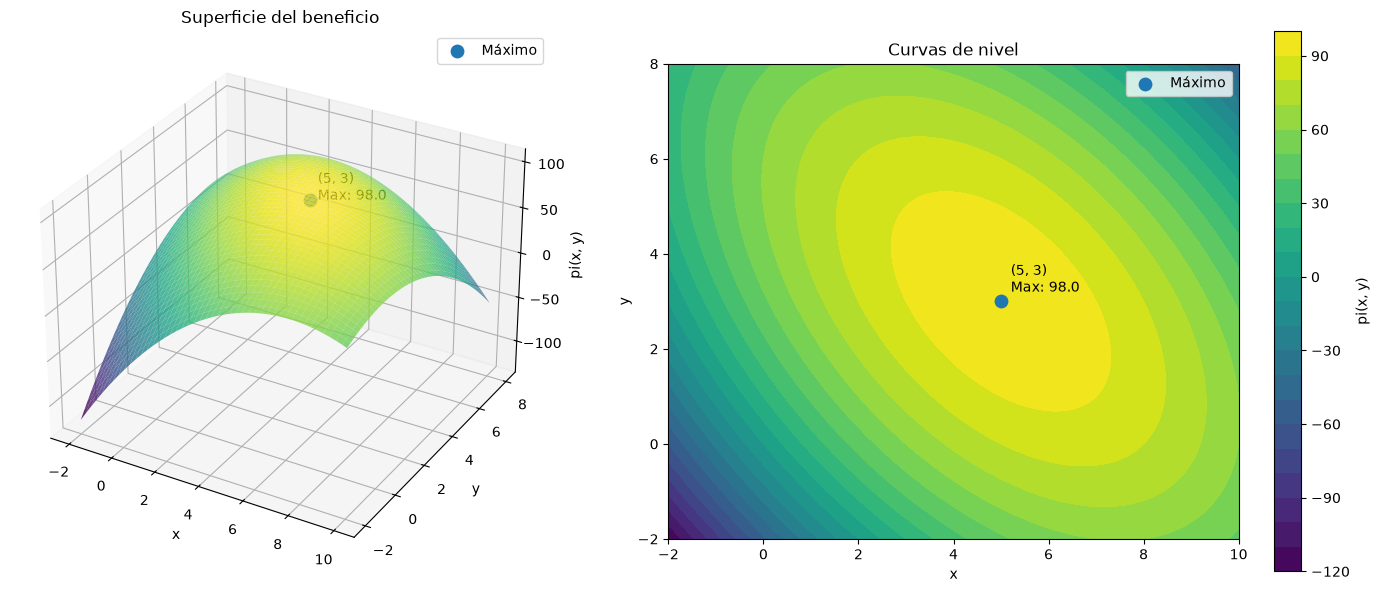

In [10]:
# Función numérica para las gráficas.
beneficio_2_np = sp.lambdify((x, y), beneficio_2, 'numpy')

x_valores = np.linspace(-2, 10, 180)
y_valores = np.linspace(-2, 8, 180)
X, Y = np.meshgrid(x_valores, y_valores)
Z = beneficio_2_np(X, Y)

x_opt_2 = float(x_star_2)
y_opt_2 = float(y_star_2)
z_opt_2 = float(beneficio_star_2)

fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.80, edgecolor='none')
ax1.scatter(x_opt_2, y_opt_2, z_opt_2, s=80, label='Máximo')
ax1.text(x_opt_2, y_opt_2, z_opt_2, f'  (5, 3)\n  Max: {z_opt_2:.1f}', fontsize=10)
ax1.set_title('Superficie del beneficio')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('pi(x, y)')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
contorno = ax2.contourf(X, Y, Z, levels=25, cmap='viridis')
ax2.scatter(x_opt_2, y_opt_2, s=80, label='Máximo')
ax2.annotate(f'(5, 3)\nMax: {z_opt_2:.1f}', (x_opt_2, y_opt_2),
             xytext=(7, 7), textcoords='offset points')
ax2.set_title('Curvas de nivel')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
fig.colorbar(contorno, ax=ax2, label='pi(x, y)')

plt.tight_layout()
plt.show()


## 3.2. Comprobación numérica: ascenso por gradiente

Aplicaremos la regla iterativa de la subsección 2.5 a la función de beneficio de dos productos, cuya solución exacta ya conocemos:

$$
(x^*,y^*)=(5,3).
$$

Esto permite comparar la solución iterativa con la solución obtenida mediante `sp.solve()`.

In [11]:
# 1. Convertimos el gradiente simbólico en una función numérica.
# sp.lambdify transforma la expresión matemática de SymPy en una función rápida que NumPy puede evaluar.
grad_beneficio_2_np = sp.lambdify((x, y), grad_beneficio_2, 'numpy')

# 2. Configuración inicial del algoritmo.
# Empezamos la búsqueda desde el origen (0, 0).
punto_gradiente = np.array([0.0, 0.0])

# 'alpha' es el tamaño de paso (a veces llamado tasa de aprendizaje).
# Determina cuánto avanzamos en la dirección del gradiente en cada iteración.
alpha = 0.10

# 'numero_iteraciones' es la cantidad de pasos que daremos.
numero_iteraciones = 30

# 'trayectoria' es una lista donde guardaremos todos los puntos visitados para poder graficarlos después.
trayectoria = [punto_gradiente.copy()]

# 3. Bucle principal del algoritmo iterativo.
for k in range(numero_iteraciones):
    # a. Evaluamos el vector gradiente en el punto actual.
    # El asterisco (*) separa el arreglo en las coordenadas x e y que necesita la función.
    gradiente_actual = np.array(
        grad_beneficio_2_np(*punto_gradiente),
        dtype=float
    ).reshape(2)

    # b. Regla de actualización: nuevo_punto = punto_actual + paso * gradiente
    # Hacemos una SUMA (ascenso) porque queremos encontrar el MÁXIMO (subir la montaña).
    # Si buscáramos un mínimo (como minimizar costos), restaríamos (descenso por gradiente).
    punto_gradiente = punto_gradiente + alpha * gradiente_actual

    # c. Guardamos el nuevo punto en nuestra historia.
    trayectoria.append(punto_gradiente.copy())

# Convertimos la lista de puntos a una matriz de NumPy para facilitar su uso posterior.
trayectoria = np.array(trayectoria)

# 4. Mostramos los resultados obtenidos tras las iteraciones.
print('Punto aproximado:', punto_gradiente)
print('Solución exacta: [5, 3]')
# Calculamos la distancia recta (error euclídeo) entre nuestra aproximación y la solución real.
print('Error euclídeo:', np.linalg.norm(punto_gradiente - np.array([5.0, 3.0])))


Punto aproximado: [4.99876206 3.00123794]
Solución exacta: [5, 3]
Error euclídeo: 0.0017507115929618609


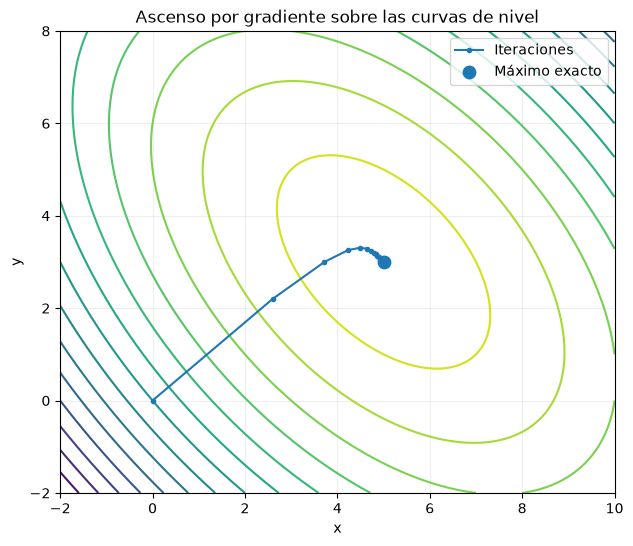

In [12]:
# Trayectoria sobre las curvas de nivel.
plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=20)
plt.plot(trayectoria[:, 0], trayectoria[:, 1], marker='o', markersize=3,
         label='Iteraciones')
plt.scatter(5, 3, s=80, label='Máximo exacto')
plt.title('Ascenso por gradiente sobre las curvas de nivel')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(alpha=0.2)
plt.legend()
plt.show()


## 3.3. Ejercicio: Optimización analítica de una función polinómica

A continuación, aplicaremos la ruta analítica utilizando `SymPy` para encontrar y clasificar los puntos críticos de la siguiente función:

$$
f(x,y) = x^3 + y^3 + 9xy
$$

Los pasos que seguiremos son:
1. Definir la función de forma simbólica.
2. Calcular el gradiente $\nabla f(x,y)$.
3. Encontrar los candidatos a puntos críticos resolviendo $\nabla f(x,y) = 0$ (Condiciones de Primer Orden).
4. Calcular la matriz Hessiana $H_f(x,y)$.
5. Clasificar cada punto crítico evaluando los autovalores de la Hessiana en dicho punto.

In [13]:
# 1. Definir variables y función
import sympy as sp
import numpy as np
x, y = sp.symbols('x y', real=True)
variables = (x, y)
f = x**3 + y**3 + 9*x*y

print('Función f(x, y):')
display(f)

# 2. Calcular el gradiente
grad_f = sp.Matrix([
    sp.diff(f, x),
    sp.diff(f, y)
])
print('\nGradiente:')
display(grad_f)

# 3. Encontrar puntos críticos (CPO)
soluciones = sp.solve(list(grad_f), variables, dict=True)
print('\nPuntos críticos (CPO):')
display(soluciones)

# 4. Calcular la Hessiana
H_f = sp.hessian(f, variables)
print('\nHessiana:')
display(H_f)

# 5. Clasificar cada punto crítico usando la Hessiana
tol = 1e-8
print('\n--- Clasificación de los puntos críticos ---')
for sol in soluciones:
    # Evaluar Hessiana en el punto crítico
    H_critico = H_f.subs(sol)
    # Convertir a numpy para calcular autovalores
    H_np = np.array(H_critico.tolist(), dtype=float)
    autovalores = np.linalg.eigvalsh(H_np)

    # Clasificación por autovalores
    if np.all(autovalores > tol):
        clasificacion = 'Mínimo local estricto'
    elif np.all(autovalores < -tol):
        clasificacion = 'Máximo local estricto'
    elif np.any(autovalores > tol) and np.any(autovalores < -tol):
        clasificacion = 'Punto de silla'
    else:
        clasificacion = 'Prueba inconclusa (semidefinida)'

    print(f'\nPunto crítico: x = {sol[x]}, y = {sol[y]}')
    print('Hessiana en el punto:')
    display(H_critico)
    print(f'Autovalores: {autovalores}')
    print(f'Clasificación: {clasificacion}')


Función f(x, y):


 3            3
x  + 9⋅x⋅y + y 


Gradiente:


⎡   2      ⎤
⎢3⋅x  + 9⋅y⎥
⎢          ⎥
⎢         2⎥
⎣9⋅x + 3⋅y ⎦


Puntos críticos (CPO):


...


--- Clasificación de los puntos críticos ---

Punto crítico: x = -3, y = -3
Hessiana en el punto:


⎡-18   9 ⎤
⎢        ⎥
⎣ 9   -18⎦

Autovalores: [-27.  -9.]
Clasificación: Máximo local estricto

Punto crítico: x = 0, y = 0
Hessiana en el punto:


⎡0  9⎤
⎢    ⎥
⎣9  0⎦

Autovalores: [-9.  9.]
Clasificación: Punto de silla


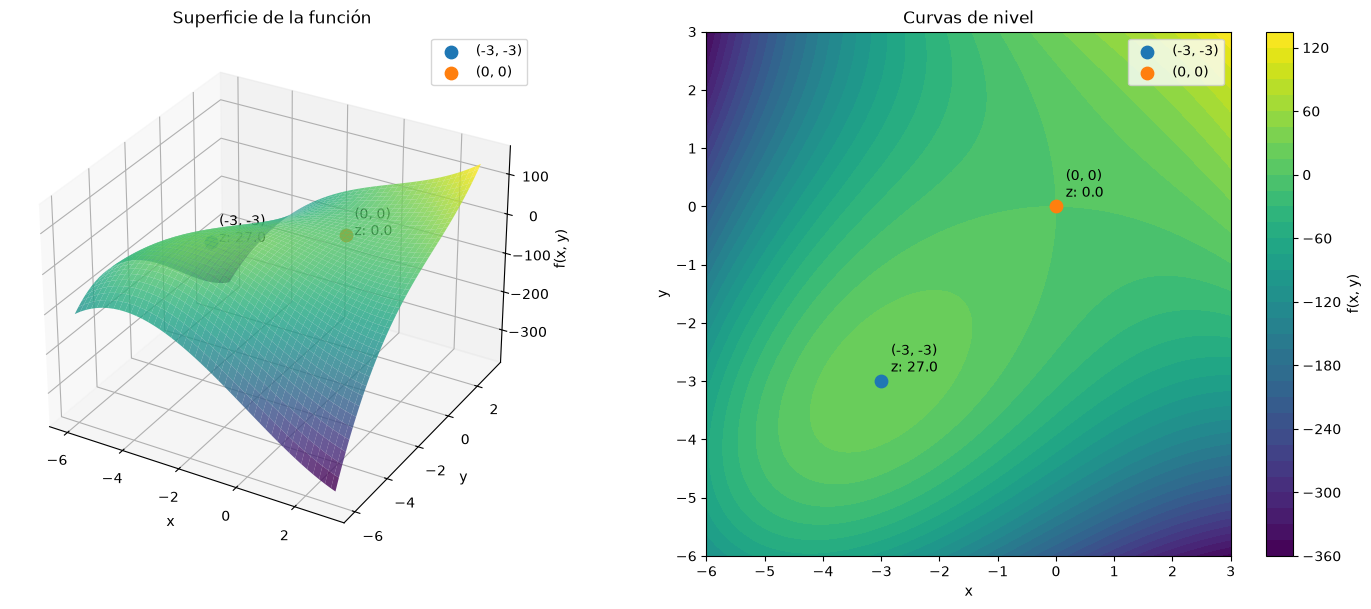

In [14]:
# Función numérica para las gráficas.
f_np = sp.lambdify((x, y), f, 'numpy')

# Definir el rango de evaluación
x_valores = np.linspace(-6, 3, 180)
y_valores = np.linspace(-6, 3, 180)
X, Y = np.meshgrid(x_valores, y_valores)
Z = f_np(X, Y)

fig = plt.figure(figsize=(15, 6))

# Gráfico 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.80, edgecolor='none')

# Marcar puntos críticos en 3D
for sol in soluciones:
    x_opt = float(sol[x])
    y_opt = float(sol[y])
    z_opt = float(f.subs(sol))

    # Diferenciar el color por punto
    label_name = 'Punto crítico'
    ax1.scatter(x_opt, y_opt, z_opt, s=80, label=f'({x_opt:.0f}, {y_opt:.0f})')
    ax1.text(x_opt, y_opt, z_opt, f'  ({x_opt:.0f}, {y_opt:.0f})\n  z: {z_opt:.1f}', fontsize=10)

ax1.set_title('Superficie de la función')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
ax1.legend()

# Gráfico 2D (Curvas de nivel)
ax2 = fig.add_subplot(1, 2, 2)
contorno = ax2.contourf(X, Y, Z, levels=35, cmap='viridis')

# Marcar puntos críticos en 2D
for sol in soluciones:
    x_opt = float(sol[x])
    y_opt = float(sol[y])
    z_opt = float(f.subs(sol))

    ax2.scatter(x_opt, y_opt, s=80, label=f'({x_opt:.0f}, {y_opt:.0f})')
    ax2.annotate(f'({x_opt:.0f}, {y_opt:.0f})\nz: {z_opt:.1f}', (x_opt, y_opt),
                 xytext=(7, 7), textcoords='offset points')

ax2.set_title('Curvas de nivel')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
fig.colorbar(contorno, ax=ax2, label='f(x, y)')

plt.tight_layout()
plt.show()


In [15]:
# Para que este código funcione en VS Code (VSC), asegúrate de instalar la biblioteca 'plotly'.
# Puedes instalarla ejecutando en tu terminal: pip install plotly
# O si prefieres instalarlo directamente desde este notebook, descomenta la siguiente línea:
#%pip install plotly
import plotly.graph_objects as go

# Crear la superficie 3D con curvas de nivel proyectadas en la base
fig_plotly = go.Figure(data=[go.Surface(
    z=Z, x=X, y=Y,
    colorscale='Viridis',
    opacity=0.8,
    contours=dict(
        z=dict(
            show=True,
            usecolormap=True,
            project_z=True  # Esto dibuja las curvas de nivel en el "suelo" del gráfico 3D
        )
    )
)])

# Añadir los puntos críticos
for sol in soluciones:
    x_opt = float(sol[x])
    y_opt = float(sol[y])
    z_opt = float(f.subs(sol))

    fig_plotly.add_trace(go.Scatter3d(
        x=[x_opt],
        y=[y_opt],
        z=[z_opt],
        mode='markers+text',
        marker=dict(size=8, color='red'),
        text=[f'({x_opt:.0f}, {y_opt:.0f}, {z_opt:.0f})'],
        textposition='top center',
        name='Punto crítico'
    ))

# Configurar el diseño
fig_plotly.update_layout(
    title='Superficie de f(x, y) = x^3 + y^3 + 9xy (Interactivo) con Curvas de Nivel',
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='f(x, y)'
    ),
    width=800,
    height=600,
    showlegend=False
)

fig_plotly.show()


## 3.4. Opcional: empresa con tres líneas de producción: $\mathbb{R}^3\to\mathbb{R}$

Sea

$$
\Pi(x_1,x_2,x_3)
=200-(x_1-4)^2-2(x_2-3)^2-3(x_3-2)^2-(x_1-4)(x_2-3).
$$

Ahora:

- $\mathbf{x}$ tiene dimensión $3\times1$;
- $\nabla\Pi$ tiene dimensión $3\times1$;
- $H_\Pi$ tiene dimensión $3\times3$;
- los tres autovalores de $H_\Pi$ deciden la clasificación.

In [16]:
# Variables y función.
x1, x2, x3 = sp.symbols('x1 x2 x3', real=True)
variables_3 = (x1, x2, x3)

beneficio_3 = (
    200
    - (x1 - 4)**2
    - 2*(x2 - 3)**2
    - 3*(x3 - 2)**2
    - (x1 - 4)*(x2 - 3)
)

# Gradiente 3 x 1.
grad_beneficio_3 = sp.Matrix([
    sp.diff(beneficio_3, x1),
    sp.diff(beneficio_3, x2),
    sp.diff(beneficio_3, x3)
])

# CPO.
soluciones_3 = sp.solve(list(grad_beneficio_3), variables_3, dict=True)
solucion_3 = soluciones_3[0]

print('Gradiente:')
display(grad_beneficio_3)
print('Dimensión:', grad_beneficio_3.shape)
print('Punto crítico:')
display(solucion_3)


Gradiente:


⎡-2⋅x₁ - x₂ + 11⎤
⎢               ⎥
⎢-x₁ - 4⋅x₂ + 16⎥
⎢               ⎥
⎣   12 - 6⋅x₃   ⎦

Dimensión: (3, 1)
Punto crítico:


{x₁: 4, x₂: 3, x₃: 2}

In [17]:
# Hessiana 3 x 3.
H_beneficio_3 = sp.hessian(beneficio_3, variables_3)
H_3_critico = H_beneficio_3.subs(solucion_3)

print('Hessiana:')
display(H_3_critico)
print('Dimensión:', H_3_critico.shape)

Hessiana:


⎡-2  -1  0 ⎤
⎢          ⎥
⎢-1  -4  0 ⎥
⎢          ⎥
⎣0   0   -6⎦

Dimensión: (3, 3)


In [18]:
# Autovalores de la Hessiana simétrica con tolerancia numérica.
H_3_np = np.array(H_3_critico.tolist(), dtype=float)
autovalores_3 = np.linalg.eigvalsh(H_3_np)
tol = 1e-8

if np.all(autovalores_3 > tol):
    clasificacion_autovalores_3 = 'mínimo local estricto'
elif np.all(autovalores_3 < -tol):
    clasificacion_autovalores_3 = 'máximo local estricto'
elif np.any(autovalores_3 > tol) and np.any(autovalores_3 < -tol):
    clasificacion_autovalores_3 = 'punto de silla'
else:
    clasificacion_autovalores_3 = 'semidefinida o criterio inconcluso'

beneficio_star_3 = sp.simplify(beneficio_3.subs(solucion_3))

print('Autovalores:', autovalores_3)
print('Tolerancia numérica:', tol)
print('Clasificación por autovalores:', clasificacion_autovalores_3)
print('Beneficio máximo =', beneficio_star_3)

assert solucion_3 == {x1: 4, x2: 3, x3: 2}
assert beneficio_star_3 == 200
assert clasificacion_autovalores_3 == 'máximo local estricto'


Autovalores: [-6.         -4.41421356 -1.58578644]
Tolerancia numérica: 1e-08
Clasificación por autovalores: máximo local estricto
Beneficio máximo = 200


Como todos los autovalores son negativos, la Hessiana es negativa definida. La función es estrictamente cóncava y el punto crítico es el máximo global único.

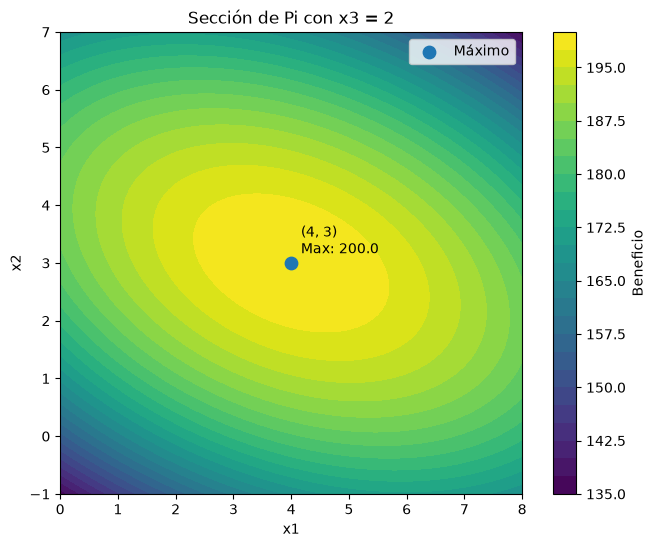

In [19]:
# Una función de tres entradas necesitaría cuatro dimensiones para representarse.
# Fijamos x3 en su valor óptimo y graficamos una sección en (x1, x2).
x3_star = solucion_3[x3]
beneficio_3_seccion = sp.simplify(beneficio_3.subs(x3, x3_star))
beneficio_3_seccion_np = sp.lambdify((x1, x2), beneficio_3_seccion, 'numpy')

x1_valores = np.linspace(0, 8, 180)
x2_valores = np.linspace(-1, 7, 180)
X1, X2 = np.meshgrid(x1_valores, x2_valores)
Z3 = beneficio_3_seccion_np(X1, X2)

plt.figure(figsize=(8, 6))
contorno_3 = plt.contourf(X1, X2, Z3, levels=25, cmap='viridis')
plt.scatter(4, 3, s=80, label='Máximo')
plt.annotate(f'(4, 3)\nMax: {float(beneficio_star_3):.1f}', (4, 3), xytext=(7, 7), textcoords='offset points')
plt.title('Sección de Pi con x3 = 2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.gca().set_aspect('equal', adjustable='box')
plt.colorbar(contorno_3, label='Beneficio')
plt.legend()
plt.show()


# 4. Resumen comparativo

| Caso | Valor | Primera derivada | Segunda derivada | Optimización clásica |
|---|---:|---|---|---|
| $f:\mathbb{R}\to\mathbb{R}$ | escalar | $f'$ escalar | $f''$ escalar | $f'=0$ y signo de $f''$ |
| $F:\mathbb{R}^2\to\mathbb{R}$ | escalar | $\nabla F$: $2\times1$ | $H_F$: $2\times2$ | CPO y criterio $D$ |
| $F:\mathbb{R}^n\to\mathbb{R}$ | escalar | $\nabla F$: $n\times1$ | $H_F$: $n\times n$ | CPO y autovalores (menores a mano) |

## Ruta analítica común

```python
# 1. Declarar símbolos.
# 2. Definir la función escalar.
# 3. Calcular el gradiente con sp.diff().
# 4. Resolver las CPO con sp.solve().
# 5. Calcular la Hessiana con sp.hessian().
# 6. Comprobar autovalores con np.linalg.eigvalsh().
# 7. Evaluar y graficar el óptimo.
# 8. (Opcional) Comprobar con ascenso por gradiente.
```

# 5. Errores frecuentes

1. **Confundir el gradiente con su transpuesta.** El gradiente es un vector columna $n\times1$; en la aproximación de Taylor aparece $\nabla F^T$ ($1\times n$) para que $\nabla F^T\mathbf{h}$ sea un escalar.
2. **Ignorar las dimensiones.** Antes de multiplicar matrices, compruebe que las dimensiones interiores coincidan.
3. **Creer que la CPO clasifica el punto.** $\nabla F=0$ solo identifica candidatos.
4. **Concluir indefinición porque falla el patrón de menores líderes.** La matriz también podría ser semidefinida.
5. **Usar `eigvals` en una Hessiana simétrica.** `eigvalsh` aprovecha la simetría y devuelve autovalores reales.
6. **Usar descenso para maximizar.** Para beneficio o utilidad se usa ascenso, o se minimiza el negativo.
7. **Presentar el gradiente iterativo antes de dominar CPO y CSO.** El algoritmo se entiende mejor después de la teoría analítica.
8. **Esperar una solución exacta del gradiente numérico.** Es un procedimiento aproximado y depende del paso y del punto inicial.

# 6. Práctica autónoma

## A. Función $\mathbb{R}\to\mathbb{R}$

Optimice y grafique

$$
g(q)=-2q^2+48q-80.
$$

## B. Función $\mathbb{R}^2\to\mathbb{R}$

Optimice, clasifique el punto crítico con los autovalores de la Hessiana y grafique

$$
g(x,y)=-x^2-2y^2-xy+10x+12y.
$$

(Opcional: compruebe a mano con los menores líderes $\Delta_1$ y $\Delta_2$.)

## C. Función $\mathbb{R}^3\to\mathbb{R}$

Optimice

$$
g(x_1,x_2,x_3)
=150-(x_1-2)^2-(x_2-4)^2-2(x_3-1)^2.
$$

Compruebe la clasificación con los tres autovalores (`np.linalg.eigvalsh`). (Opcional: verifique a mano los tres menores principales líderes.)

## D. Ascenso por gradiente

Cambie el tamaño de paso del ascenso por gradiente a

$$
\alpha\in\{0.02,0.10,0.30,0.40\}
$$

y compare las trayectorias. Explique qué ocurre cuando el paso es demasiado grande.

In [26]:
# Comprobación final de los resultados principales.
assert q_star == 20
assert beneficio_star_q == 300

assert solucion_2 == {x: 5, y: 3}
assert beneficio_star_2 == 98

assert solucion_3 == {x1: 4, x2: 3, x3: 2}
assert beneficio_star_3 == 200

print('Todas las comprobaciones del notebook se ejecutaron correctamente.')

Todas las comprobaciones del notebook se ejecutaron correctamente.
